In [ ]:
import pandas as pd

In [ ]:
data = { 'Name': ['A', 'B', 'C'], 'B': [85, 90, 78], 'City': ['Ahmedabad', 'Delhi', 'Mumbai'] } 
df = pd.DataFrame(data,columns=["A","B","C"]) 
df

,A,B,C
0,NaN,85,NaN
1,NaN,90,NaN
2,NaN,78,NaN


In [ ]:
s1 = pd.Series([1,2,3]) 
s2 = pd.Series([4,5,6]) 
df = pd.DataFrame({'col1':s1,'col2':s2}) 
df.set_index("col1",  inplace=True) 
df

,col2
col1,
1,4
2,5
3,6


In [ ]:
data = { "name": ["Kohli", "Rohit", None, "Rahul"], "runs": [12000, 11000, 3500, 4200], "avg": [None, 48.7, 51.2, 45.3] } 
df = pd.DataFrame(data) 
print(df)

df.fillna(method="bfill",inplace=True)
df

    name   runs   avg
0  Kohli  12000   NaN
1  Rohit  11000  48.7
2   None   3500  51.2
3  Rahul   4200  45.3


C:\Users\Admin\AppData\Local\Temp\ipykernel_6660\2819739381.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="bfill",inplace=True)


,name,runs,avg
0,Kohli,12000,48.7
1,Rohit,11000,48.7
2,Rahul,3500,51.2
3,Rahul,4200,45.3


In [ ]:
df.sort_values(by='name', ascending=True)   # ascending
df.sort_values(by='name', ascending=False)  # descending

# col1 ascending, col2 descending
df.sort_values(by=['name','avg'], ascending=True)



,name,runs,avg
0,Kohli,12000,48.7
3,Rahul,4200,45.3
2,Rahul,3500,51.2
1,Rohit,11000,48.7


In [ ]:
df1 = pd.DataFrame({    "Maths": [80, 85, 90],    "Science": [78, 82, 88],    "English": [70, 75, 80] }) 
result = df1.apply(sum , axis=1) 
result

0    228
1    242
2    258
dtype: int64

In [ ]:
df5 = pd.DataFrame({    "Marks1": [85, 70, 90],    "Marks2": [80, 65, 95],    "Marks3": [75, 60, 85] }) 
def grade(x):    
    if x['Total'] >= 250:        
        return "A"    
    elif x['Total'] >= 200:        
        return "B"    
    else:        
        return "C" 
df5["Total"] = df5.apply(lambda x: x.sum(), axis=1) 

df5["Grade"] = df5.apply(grade,axis=1) 
print(df5)

   Marks1  Marks2  Marks3  Total Grade
0      85      80      75    240     B
1      70      65      60    195     C
2      90      95      85    270     A


In [ ]:
df = pd.DataFrame({
    'dept':   ['HR','IT','HR','IT','HR','IT'],
    'gender': ['M','F','F','M','M','F'],
    'salary': [40000,80000,45000,90000,42000,85000],
    'age':    [25,30,35,28,40,33]
})

In [ ]:
# 1. Total salary by department
df.groupby('dept')[['salary','age']].sum()

,salary,age
dept,,
HR,127000,100
IT,255000,91


In [ ]:
# 4. Add group mean back to df
df['avg_dept_salary'] = df.groupby('dept')['salary'].transform('mean')
df

,dept,gender,salary,age,avg_dept_salary
0,HR,M,40000,25,42333.333333
1,IT,F,80000,30,85000.000000
2,HR,F,45000,35,42333.333333
3,IT,M,90000,28,85000.000000
4,HR,M,42000,40,42333.333333
5,IT,F,85000,33,85000.000000


In [ ]:
df[['salary' , 'age']].apply(sum , axis=1 , args=(5,))

0    40030
1    80035
2    45040
3    90033
4    42045
5    85038
dtype: int64

In [ ]:
df[['salary' , 'age']].apply(sum , axis=1)

0    40025
1    80030
2    45035
3    90028
4    42040
5    85033
dtype: int64

In [ ]:
df = pd.DataFrame({
    'dept':   ['HR','IT','HR','IT','HR','IT'],
    'gender': ['M','F','F','M','M','F'],
    'salary': [40000,80000,45000,90000,42000,85000],
    'age':    [25,30,35,28,40,33],
})
df

,dept,gender,salary,age
0,HR,M,40000,25
1,IT,F,80000,30
2,HR,F,45000,35
3,IT,M,90000,28
4,HR,M,42000,40
5,IT,F,85000,33


In [ ]:
df1 = pd.DataFrame({
    'a' : [1,2,3] , 
    'b' : [4,5,6]
})
df2 = pd.DataFrame({
    'a' : [7,8,9] , 
    'c' : [14,15,16]
})

pd.concat([df1,df2] ,join='inner')

,a
0,1
1,2
2,3
0,7
1,8
2,9


In [ ]:
df2.describe(percentiles=(0.51,))

,a,c
count,3.00,3.00
mean,8.00,15.00
std,1.00,1.00
min,7.00,14.00
50%,8.00,15.00
51%,8.02,15.02
max,9.00,16.00


In [ ]:
df = pd.DataFrame({
    "A": [1, None, 3],
    "B": [4, 4, None],
    "C": [7, 8, 9]
})
df

,A,B,C
0,1.0,4.0,7
1,NaN,4.0,8
2,3.0,NaN,9


In [ ]:
df.dropna(subset=[1,2] , axis=1 , how='all')

,A,B,C
0,1.0,4.0,7
1,NaN,4.0,8
2,3.0,NaN,9


In [ ]:
df = pd.DataFrame({
    'salary': [40,6,14,9,42,85],
    'age':    [25,10,35,None,40,None],
})
df

,salary,age
0,40,25.0
1,6,10.0
2,14,35.0
3,9,NaN
4,42,40.0
5,85,NaN


In [ ]:
df.sort_values( by='age',  axis=0 , na_position='first' )

,salary,age
3,9,NaN
5,85,NaN
1,6,10.0
0,40,25.0
2,14,35.0
4,42,40.0


In [ ]:
df.sort_index(na_position='first')

,salary,age
0,40,25.0
1,6,10.0
2,14,35.0
3,9,NaN
4,42,40.0
5,85,NaN


In [ ]:
df

,salary,age
0,40,25.0
1,6,10.0
2,14,35.0
3,9,NaN
4,42,40.0
5,85,NaN


array([[<Axes: xlabel='salary', ylabel='salary'>,
        <Axes: xlabel='age', ylabel='salary'>],
       [<Axes: xlabel='salary', ylabel='age'>,
        <Axes: xlabel='age', ylabel='age'>]], dtype=object)

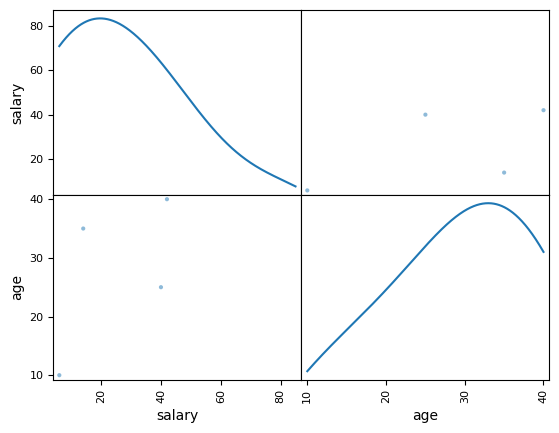

In [ ]:
pd.plotting.scatter_matrix(df , diagonal='kde' , hist_kwds={'color' : 'red'})

In [ ]:
df = pd.DataFrame({
    'dept':   ['HR','IT','HR','IT','HR','IT' , 'Other'],
    'gender': ['M','F','F','M','M','F' , 'F'],
    'salary': [40000,80000,45000,90000,42000,85000 , 32355],
    'age':    [25000,30000,35000,28000,40000,33000 , 5323253],
    'ex':    [55000,54000,89000,59000,15000,90000 , 325325],
})
df

,dept,gender,salary,age,ex
0,HR,M,40000,25000,55000
1,IT,F,80000,30000,54000
2,HR,F,45000,35000,89000
3,IT,M,90000,28000,59000
4,HR,M,42000,40000,15000
5,IT,F,85000,33000,90000
6,Other,F,32355,5323253,325325


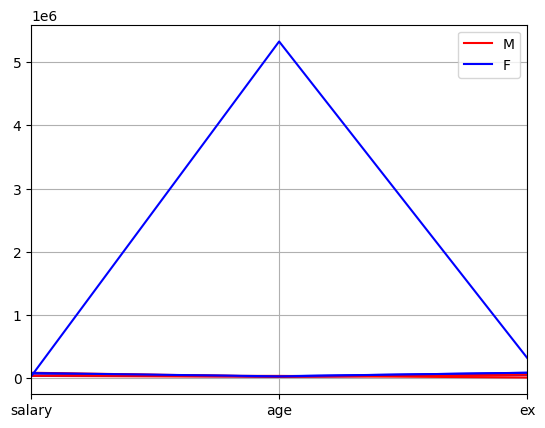

In [ ]:
import matplotlib.pyplot as plt

pd.plotting.parallel_coordinates(df , 'gender' , ['salary' , 'age' , 'ex'] , color=['red' , 'blue' ] , axvlines=False)
plt.show()

In [ ]:
pd.crosstab( df['gender'] , df['dept'] , rownames=['Gender'] , colnames=['DEPT'] , margins=True , margins_name='val1' , normalize='columns' )

DEPT,HR,IT,Other,val1
Gender,,,,
F,0.333333,0.666667,1.0,0.571429
M,0.666667,0.333333,0.0,0.428571


In [ ]:
df1 = pd.DataFrame({
    'a' : [1,None,3] , 
    'b' : [4,5,6]
})
df2 = pd.DataFrame({
    'a' : [7,8,9] , 
    'c' : [14,15,16]
})

df1.merge(df2 , how='outer')

,a,b,c
0,1.0,4.0,NaN
1,3.0,6.0,NaN
2,7.0,NaN,14.0
3,8.0,NaN,15.0
4,9.0,NaN,16.0
5,NaN,5.0,NaN


In [ ]:
df1.fillna({"a2" : 70})

,a,b
0,1.0,4
1,NaN,5
2,3.0,6


In [ ]:
df1.drop(axis=1 , index=10 , errors='ignore')

,a,b
0,1.0,4
1,NaN,5
2,3.0,6


In [ ]:
import pandas as pd
import numpy as np
df=pd.DataFrame([[0,1,2,np.nan,5],[2,0,1,5,np.nan],[5,0,1,np.nan,5],[2,0,1,np.nan,np.nan]])
print(df)
# df=df.drop_duplicates(subset=[1,2])
# df
# df=df.drop_duplicates(subset=[4])
# df.dropna(thresh=2,axis=1)
# print(df.shape)

   0  1  2    3    4
0  0  1  2  NaN  5.0
1  2  0  1  5.0  NaN
2  5  0  1  NaN  5.0
3  2  0  1  NaN  NaN


In [ ]:
import pandas as pd
data = {
"Student": ["A","B","C","D","E"],
"Math": [78, 90, 67, 88, 90],
"Science": [85, 92, 70, 88, 85]
}
df = pd.DataFrame(data , index=[1,2,3,4,5])
print(df)
# result = df.sort_values(by=["Math","Science"], ascending=[False,True])
# print(result.head(1)["Student"].values[0])

  Student  Math  Science
1       A    78       85
2       B    90       92
3       C    67       70
4       D    88       88
5       E    90       85


In [ ]:
df.index[[0,3]]

Index([1, 4], dtype='int64')

In [ ]:
# df["C"]

KeyError: 'C'

In [ ]:
import pandas as pd
df = pd.DataFrame({
"Team":["X","Y","X","Y","X"],
"Runs":[50,60,70,80,90]
})
result = df.groupby("Team")["Runs"].mean()
print(result)
# print(result["X"])

Team
X    70.0
Y    70.0
Name: Runs, dtype: float64


In [ ]:


import pandas as pd
df = pd.DataFrame({
"Dept":["IT","HR","IT","HR","IT","Finance"]
})
print(df.groupby("Dept").size()["IT"])


3


In [ ]:

import pandas as pd
df = pd.DataFrame({
    "Category":["A","A","B","B"],
    "Value":[10,20,30,40]
})
result = df.groupby("Category").nunique().shape
print(result)

(2, 1)


In [ ]:
import pandas as pd
df = pd.DataFrame({
"City":["A","A","B","C","C","C"]
})
print(df.groupby("City").nunique())

Empty DataFrame
Columns: []
Index: [A, B, C]


In [ ]:
import pandas as pd
df = pd.DataFrame({
"Team":["X","X","Y","Y"],
"Score":[10,20,30,40]
})
result = df.groupby("Team").nth(0)
print(result)

  Team  Score
0    X     10
2    Y     30


In [ ]:
import pandas as pd
df = pd.DataFrame({
"Team":["A" , 'B' ,"A","B","B" , "B"],
"Score":[10 , 50 ,20,30,40 , 50]
})
result = df.groupby("Team").sample(2)
print(result)

  Team  Score
0    A     10
2    A     20
1    B     50
5    B     50


In [ ]:
import pandas as pd
df1 = pd.DataFrame({"ID":[1,2], "Score":[80,90] , "Mar" : [1,2]})
df2 = pd.DataFrame({"ID":[1,2], "Score":[85,95] , "Mar" : [1,2]})
result = pd.merge(df1,df2,on="ID",suffixes=("X" , "Y") , indicator=True)
# print(result.loc[0,"ScoreY"])
result

,ID,ScoreX,MarX,ScoreY,MarY,_merge
0,1,80,1,85,1,both
1,2,90,2,95,2,both


In [ ]:
import pandas as pd
df = pd.DataFrame({
"Dept":["IT","IT","HR"],
"City":["A","A","B"]
})
result = df.groupby("Dept").nunique()
print(result.loc["IT","City"])
# print(result)

1


# PB 64

In [ ]:
df = pd.read_csv("car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
df[ (df["Kms_Driven"] > 30000) & ( df["Car_Name"] == 'ritz' ) ].shape[0]

3

In [ ]:
df[ (df["Fuel_Type"] == "Petrol") & (df["Year"] == 2017) & (df["Selling_Price"] > 10) ].shape[0]

2

In [ ]:
df[ (df["Selling_Price"] < 4) & ( df["Car_Name"] == 'swift' ) ].shape[0]


1

In [ ]:
df[ (df["Transmission"] == "Automatic") 
   & (df["Year"] == 2015) &
     (df["Selling_Price"] > 10) &
       (df["Fuel_Type"] == "Petrol")  ].shape[0]

1

In [ ]:
d = df.corr(numeric_only=True)
d.loc["Present_Price" , "Selling_Price"]

np.float64(0.8789825451614949)

# PB 69

In [ ]:
df = pd.DataFrame({
# "Student":["A","B","C","D"],
"math":[70,45,90,60],
# "Science":[75,40,85,55]
})
df

,math
0,70
1,45
2,90
3,60


In [ ]:
df["math"].mean()

np.float64(66.25)

In [ ]:
df["Avg"] = df.apply(lambda x : (x["math"] + x["Science"]) / 2 , axis= 1)
df

,Student,math,Science,Avg
0,A,70,75,72.5
1,B,45,40,42.5
2,C,90,85,87.5
3,D,60,55,57.5


In [ ]:

def grade(x) :
    if x["Avg"]>= 80 :
        return "Dis"
    elif x["Avg"] >= 60 :
        return "First"
    else :
        return "Second"
df["grade"] = df.apply(grade , axis=1)
df

,Student,math,Science,Avg,grade
0,A,70,75,72.5,First
1,B,45,40,42.5,Second
2,C,90,85,87.5,Dis
3,D,60,55,57.5,Second


# PB 70

In [ ]:
df = pd.DataFrame({
"Marks":["50","60","Absent","70","Absent"]
})
df

,Marks
0,50
1,60
2,Absent
3,70
4,Absent


In [ ]:
df.replace({"Absent" : 0} , inplace=True)

df["Marks"] = df["Marks"].astype(int)
df

,Marks
0,50
1,60
2,0
3,70
4,0


In [ ]:
df["Marks"].mean()

np.float64(36.0)

# PB 73

In [ ]:
df = pd.DataFrame({
"Dept":["IT","IT","HR","HR","Finance","Finance"],
"Salary":[50000,70000,40000,60000,80000,75000]
})
df

,Dept,Salary
0,IT,50000
1,IT,70000
2,HR,40000
3,HR,60000
4,Finance,80000
5,Finance,75000


In [ ]:
df.groupby("Dept")["Salary"].agg(["mean" , 'median' , 'max'])

,mean,median,max
Dept,,,
Finance,77500.0,77500.0,80000
HR,50000.0,50000.0,60000
IT,60000.0,60000.0,70000


# PB 74

In [ ]:
df = pd.DataFrame({
"Team":["A","A","A","B","B"],
"Runs":[50,70,80,40,60]
})
df

,Team,Runs
0,A,50
1,A,70
2,A,80
3,B,40
4,B,60


In [ ]:
df.groupby("Team").apply(lambda x : x.max() - x.min())

,Runs
Team,
A,30
B,20


# PB 76

In [ ]:
df = pd.DataFrame({
"Dept":["IT","IT","HR","HR","Finance","Finance"],
"Employee":["A","B","C","D","E","F"],
"City":["X","X","Y","Z","X","Y"]
})
df

,Dept,Employee,City
0,IT,A,X
1,IT,B,X
2,HR,C,Y
3,HR,D,Z
4,Finance,E,X
5,Finance,F,Y


In [ ]:
df.groupby("Dept").nunique()

,Employee,City
Dept,,
Finance,2,2
HR,2,2
IT,2,1


In [ ]:
df.groupby("Dept").nth(1)


,Dept,Employee,City
1,IT,B,X
3,HR,D,Z
5,Finance,F,Y


In [1]:
import pandas as pd

In [2]:
df = pd.DataFrame({
    "A" : [None , None , 5 , None , None , None ],
    "b" : [None , None , 5 , None , None , None ]
})

df

,A,b
0,NaN,NaN
1,NaN,NaN
2,5.0,5.0
3,NaN,NaN
4,NaN,NaN
5,NaN,NaN


In [3]:
df.fillna(2 , limit=4)

,A,b
0,2.0,2.0
1,2.0,2.0
2,5.0,5.0
3,2.0,2.0
4,2.0,2.0
5,NaN,NaN


In [9]:
df1 = pd.DataFrame({
    "ID" : [1,2,3,4],
    "Dept": ["IT","IT","HR","HR"],
    
})

df2 = pd.DataFrame({
    "ID" : [2,3,4,5],
    "Dept": ["IT","IT","HR","HR"],
    "Salary": [50000,60000,45000,47000]
})
df1.merge(df2 , on="Dept")


,ID_x,Dept,ID_y,Salary
0,1,IT,2,50000
1,1,IT,3,60000
2,2,IT,2,50000
3,2,IT,3,60000
4,3,HR,4,45000
5,3,HR,5,47000
6,4,HR,4,45000
7,4,HR,5,47000


In [10]:
import pandas as pd

s = pd.Series([1,2,3,4])
s

0    1
1    2
2    3
3    4
dtype: int64

KeyError: 'key of type tuple not found and not a MultiIndex'

In [20]:
df = pd.DataFrame(
    {
    'A' :[1,2,3,4],
    "B":[1,2,3,4],
    "C":[None,None,None,None]}
)
df

,A,B,C
0,1,1,None
1,2,2,None
2,3,3,None
3,4,4,None


In [21]:
df.dropna(thresh=3,axis=0).shape

(0, 3)